#  Student Productivity Classification — Random Forest

**Dataset:** `ultimate_student_productivity_dataset_5000.csv`  
**Task:** Binary Classification — **Tinggi vs Rendah Produktivitas**  
**Model:** Random Forest Classifier

---
###  Daftar Isi
1. Cara Melihat Tipe Data
2. Dataset Bisa Digunakan Untuk Apa
3. Model Yang Bisa Digunakan
4. Parameter Yang Bisa Diubah/Disetel
5. Evaluasi Yang Dipakai
6. Cara Mengetahui Evaluasi Bagus atau Tidak
7. Cara Mengoptimasi Model
8. Cara Menyimpan Model
9. Cara Menggunakan Model Hasil Training

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score

print('Libraries loaded ')

Libraries loaded 


---
## 1.  Cara Melihat Tipe Data

In [2]:
df = pd.read_csv('../ultimate_student_productivity_dataset_5000.csv')
print(f'Shape: {df.shape}')
df.info()

Shape: (5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  int

---
## 2.  Dataset Bisa Digunakan Untuk Apa

In [3]:
median_score = df['productivity_score'].median()
df['high_productivity'] = (df['productivity_score'] >= median_score).astype(int)
print(f'Median: {median_score:.1f}, Distribusi: {df["high_productivity"].value_counts().to_dict()}')

target = 'high_productivity'
drop_cols = ['student_id', 'productivity_score', 'exam_score']
df_proc = df.drop(columns=drop_cols).copy()
le = LabelEncoder()
for col in df_proc.select_dtypes(include='object').columns:
    df_proc[col] = le.fit_transform(df_proc[col].astype(str))

X = df_proc.drop(columns=[target]); y = df_proc[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Median: 36.9, Distribusi: {1: 2501, 0: 2499}
Train: (4000, 18), Test: (1000, 18)


---
## 3.  Random Forest untuk Classification

Random Forest klasifikasi menggunakan **majority voting**:

$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \ldots, h_T(x)\}$$

**Keunggulan vs Logistic Regression:**
- Tidak butuh scaling
- Menangkap interaksi non-linear (misalnya: belajar keras + kurang tidur = tidak produktif)
- Feature importance lebih informatif
- Robust terhadap outlier

In [4]:
model = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_split=5,
    min_samples_leaf=2, class_weight='balanced',
    n_jobs=-1, random_state=42
)
model.fit(X_train, y_train)
print('Training ')

Training 


---
## 4.  Parameter Yang Bisa Diubah / Disetel

| Parameter | Default | Penjelasan |
|-----------|---------|------------|
| `n_estimators` | 100 | Jumlah pohon |
| `max_depth` | None | Kedalaman max |
| `class_weight` | None | `'balanced'` untuk imbalanced class |
| `max_features` | `'sqrt'` | Fitur per split |
| `min_samples_leaf` | 1 | Min sampel di leaf |
| `criterion` | `'gini'` | `'entropy'` untuk information gain |

---
## 5.  Evaluasi Yang Dipakai

In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Rendah', 'Tinggi']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

      Rendah       0.88      0.91      0.90       500
      Tinggi       0.91      0.88      0.89       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000

ROC-AUC: 0.9670


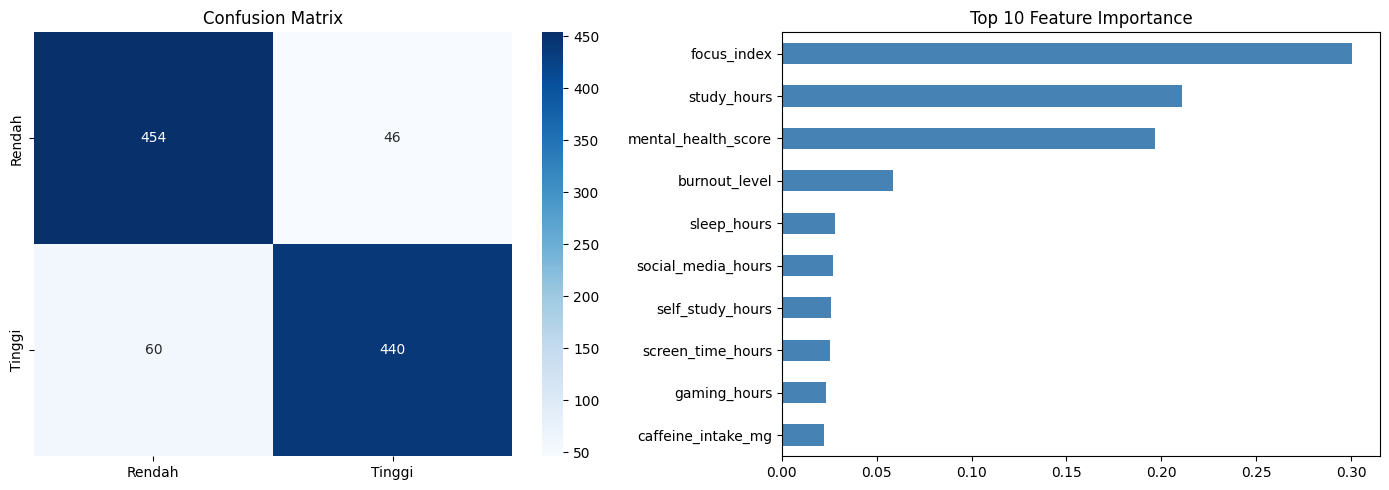

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Rendah','Tinggi'], yticklabels=['Rendah','Tinggi'])
axes[0].set_title('Confusion Matrix')

feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 10 Feature Importance')
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()

---
## 6.  Cara Mengetahui Evaluasi Bagus atau Tidak

### Khusus untuk student success prediction:
- **Recall untuk kelas 0 (Rendah)** harus tinggi → tepat mengidentifikasi yang butuh bantuan
- **ROC-AUC > 0.85** → model discriminative dengan baik
- **F1-score > 0.80** → balance precision dan recall cukup baik

In [7]:
print(f'Train Acc: {model.score(X_train, y_train):.4f}')
print(f'Test Acc : {model.score(X_test, y_test):.4f}')
print(f'AUC      : {roc_auc_score(y_test, y_prob):.4f}')

cv = cross_val_score(model, X, y, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'CV AUC   : {cv.mean():.4f} ± {cv.std():.4f}')

Train Acc: 0.9935
Test Acc : 0.8940
AUC      : 0.9670
CV AUC   : 0.9634 ± 0.0031


---
## 7.  Cara Mengoptimasi Model

In [8]:
rs = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    {'n_estimators': [100,200,300], 'max_depth': [8,12,15,None],
     'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
     'max_features': ['sqrt',0.5,0.8]},
    n_iter=12, cv=5, scoring='roc_auc', random_state=42, n_jobs=-1
)
rs.fit(X_train, y_train)
best = rs.best_estimator_
yp_b = best.predict(X_test)
yprob_b = best.predict_proba(X_test)[:,1]
print(f'Best params: {rs.best_params_}')
print(f'Best AUC: {roc_auc_score(y_test, yprob_b):.4f}')

Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 15}
Best AUC: 0.9679


---
## 8.  Cara Menyimpan Model

In [9]:
os.makedirs('saved_models', exist_ok=True)
joblib.dump(best, 'saved_models/rf_clf_productivity.pkl')
joblib.dump(list(X.columns), 'saved_models/feature_cols_rf_prod_clf.pkl')
print(' RF Classifier tersimpan!')

 RF Classifier tersimpan!


---
## 9.  Cara Menggunakan Model Hasil Training

In [10]:
loaded = joblib.load('saved_models/rf_clf_productivity.pkl')
cols   = joblib.load('saved_models/feature_cols_rf_prod_clf.pkl')
print('Model dimuat ')

students = pd.DataFrame([
    {'age': 20, 'gender': 1, 'academic_level': 1, 'study_hours': 6, 'self_study_hours': 3,
     'online_classes_hours': 2, 'social_media_hours': 1, 'gaming_hours': 0.5, 'sleep_hours': 7.5,
     'screen_time_hours': 4, 'exercise_minutes': 45, 'caffeine_intake_mg': 100,
     'part_time_job': 0, 'upcoming_deadline': 1, 'internet_quality': 2,
     'mental_health_score': 8, 'focus_index': 7, 'burnout_level': 2},
    {'age': 22, 'gender': 0, 'academic_level': 2, 'study_hours': 1.5, 'self_study_hours': 0.5,
     'online_classes_hours': 0.5, 'social_media_hours': 5, 'gaming_hours': 4, 'sleep_hours': 5,
     'screen_time_hours': 9, 'exercise_minutes': 5, 'caffeine_intake_mg': 280,
     'part_time_job': 1, 'upcoming_deadline': 0, 'internet_quality': 1,
     'mental_health_score': 4, 'focus_index': 3, 'burnout_level': 8}
])[cols]

probs = loaded.predict_proba(students)[:, 1]
preds = loaded.predict(students)
for i, (cls, p) in enumerate(zip(preds, probs)):
    r = ' Produktivitas Tinggi' if cls == 1 else ' Produktivitas Rendah'
    print(f'Mahasiswa {i+1}: {r} (prob={p:.2%})')

Model dimuat 
Mahasiswa 1:  Produktivitas Tinggi (prob=56.07%)
Mahasiswa 2:  Produktivitas Rendah (prob=30.55%)
